# 03-RNNs & Vanishing Gradients

In Lesson 02, we mapped documents into continuous vector spaces. However, TF-IDF and basic word embeddings treat a sentence as a "Bag of Words." They completely ignore **time and order**. The sentence *"The dog bit the man"* and *"The man bit the dog"* have the exact same Count Vector, despite having radically different semantic meanings.

Language is fundamentally sequential. To process text, we need a neural network architecture that possesses **memory**—one that can read a word, update its internal understanding, and carry that context forward to the next word.

Let's set up our PyTorch environment to explore the mathematics of Recurrent Neural Networks (RNNs) and visually prove why they eventually collapse under the weight of long sequences.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Sequence Modeling Environment Ready.")

✅ PyTorch Sequence Modeling Environment Ready.


# 1. The Mathematics of Recurrence

A standard Feedforward Neural Network ($y = Wx + b$) assumes all inputs are completely independent. A **Recurrent Neural Network (RNN)** breaks this assumption by introducing a **Hidden State ($h_t$)**—a mathematical memory vector that gets passed from one time step to the next.

At any given time step ($t$), the network receives two inputs:

1. The current word embedding ($x_t$).
2. The hidden state from the *previous* word ($h_{t-1}$).

The network concatenates these two vectors and mathematically merges them using a `tanh` activation function to generate the *new* hidden state:


$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

This new hidden state ($h_t$) is then used to predict the output for that specific time step ($y_t$), and is also handed off to the next time step ($t+1$).

**The Genius of Parameter Sharing:** The network does *not* have a different weight matrix for every word in the sentence. It uses the exact same $W_{hh}$ and $W_{xh}$ matrices for time step 1, time step 50, and time step 1,000. This solves the sequence length problem, allowing the network to process sentences of any arbitrary length.

# 2. Backpropagation Through Time (BPTT)

To train an RNN, we must calculate the error (Loss) at the end of the sentence and propagate the gradients backward to update the weights. Because the weights are shared across time, we must "unroll" the network backward through history. This is called **Backpropagation Through Time (BPTT)**.

If we want to know how a change in the initial hidden state ($h_0$) affects the final loss at time step $T$, we must apply the Chain Rule of calculus across every single time step in between:

$$\frac{\partial L}{\partial h_0} = \frac{\partial L}{\partial h_T} \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

# 3. The Vanishing Gradient Problem

Look closely at the product operator ($\prod$) in the BPTT equation above. We are multiplying the partial derivatives together $T$ times.

What is the derivative of the hidden state transition? Because $h_t = \tanh(W_{hh} h_{t-1} + \dots)$, the derivative with respect to $h_{t-1}$ involves the weight matrix $W_{hh}$:


$$\frac{\partial h_t}{\partial h_{t-1}} \approx W_{hh}^T \cdot \text{diag}(1 - \tanh^2(\dots))$$

### The Exponential Collapse

If the eigenvalues of the weight matrix $W_{hh}$ are less than $1.0$, multiplying a fraction by itself 100 times results in a number infinitesimally close to zero (e.g., $0.5^{100} \approx 0$).

As the error signal travels backward from the end of the sentence (time $T$) to the beginning of the sentence (time $0$), the gradient **vanishes**. By the time the network tries to update the weights for the first word, the gradient is exactly $0.0$. The network is completely blind to long-term dependencies. It mathematically **forgets** the beginning of the sentence.

# 4. The LSTM Rescue (Gating Mechanisms)

To solve the Vanishing Gradient problem, Sepp Hochreiter and Jürgen Schmidhuber invented the **Long Short-Term Memory (LSTM)** network in 1997.

Instead of multiplying the memory state by a weight matrix at every step, an LSTM introduces a **Cell State ($C_t$)** that acts as an unobstructed mathematical superhighway. The network uses "Gates" (Sigmoid functions) to carefully add or subtract information from this superhighway.

The critical mathematical breakthrough is the **Additive State Update**:


$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Because the new memory is simply the old memory *added* to the new candidate memory, the calculus derivative is no longer a massive chain of multiplications. The derivative of addition is exactly $1.0$. The gradient can flow backward across 1,000 words without vanishing!

# 5. Proving the Mathematics in PyTorch

Let's build a custom Vanilla RNN and a custom LSTM from scratch. We will feed them a sequence of 50 embedded words. We will then trigger Backpropagation and physically intercept the mathematical gradients at every single time step to visually prove the catastrophic collapse of the Vanilla RNN.

--- 🧠 Initializing Custom Recurrent Cells ---
--- ⚙️ Executing Backpropagation Through Time (BPTT) ---


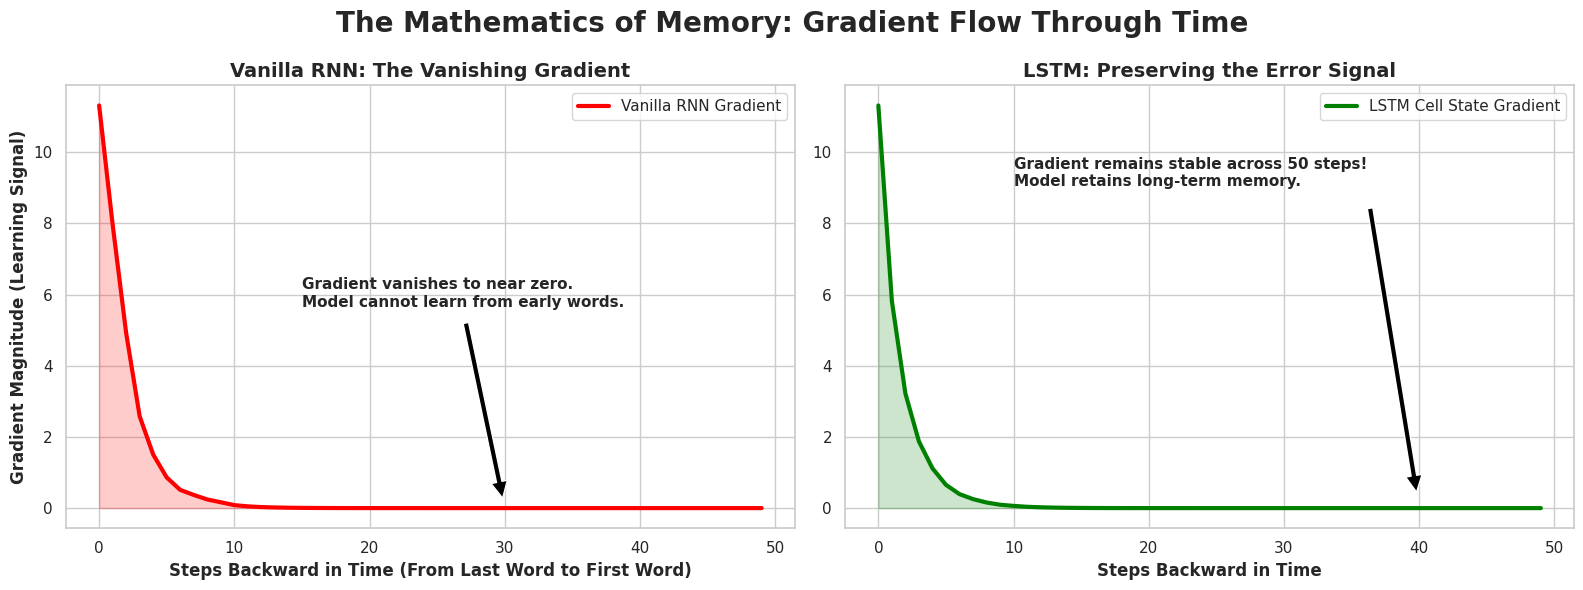


--- 💡 Engineering Insight ---
Look at the red graph. The error signal starts strong at the end of the sentence (Step 0 on the graph), but as BPTT chain-multiplies the matrices backward, the gradient violently collapses. By the time it reaches the 20th word from the end, the gradient is dead. The RNN has completely forgotten the context of the sentence.
Now look at the green graph. Because the LSTM uses an additive cell state ($C_t = f_t C_{t-1} + i_t \tilde{C}_t$), the derivative avoids the continuous multiplication trap. The error signal easily survives the 50-step journey backward, allowing the network to connect a pronoun at the end of a paragraph to a noun at the very beginning!


In [2]:
# 1. Define Sequence Dimensions
SEQ_LENGTH = 50
HIDDEN_DIM = 128
INPUT_DIM = 64

# We simulate a sentence of 50 words, where each word is a 64-dimensional embedding
# Shape: [Sequence_Length, Batch_Size, Input_Dim]
sequence = torch.randn(SEQ_LENGTH, 1, INPUT_DIM)

print("--- 🧠 Initializing Custom Recurrent Cells ---")

# 2. Architect a Custom Vanilla RNN Loop
def run_vanilla_rnn_and_get_gradients(seq):
    # Initialize shared weights
    W_xh = torch.randn(INPUT_DIM, HIDDEN_DIM, requires_grad=True) / np.sqrt(INPUT_DIM)
    W_hh = torch.randn(HIDDEN_DIM, HIDDEN_DIM, requires_grad=True) / np.sqrt(HIDDEN_DIM)
    b_h = torch.zeros(HIDDEN_DIM, requires_grad=True)
    
    h_t = torch.zeros(1, HIDDEN_DIM)
    hidden_states = []
    
    # Forward Pass through Time
    for t in range(SEQ_LENGTH):
        x_t = seq[t]
        # h_t = tanh(x*W_x + h*W_h + b)
        h_t = torch.tanh(torch.matmul(x_t, W_xh) + torch.matmul(h_t, W_hh) + b_h)
        
        # We MUST retain the gradient of intermediate variables to analyze them!
        h_t.retain_grad() 
        hidden_states.append(h_t)
        
    # Simulate a Loss at the very last time step
    final_loss = hidden_states[-1].sum()
    
    # Trigger Backpropagation Through Time (BPTT)
    final_loss.backward()
    
    # Extract the gradient magnitudes across time
    gradients = [h.grad.norm().item() for h in hidden_states]
    return gradients

# 3. Architect a Custom LSTM Loop
def run_lstm_and_get_gradients(seq):
    # PyTorch's native LSTMCell handles the gating math automatically
    lstm_cell = nn.LSTMCell(INPUT_DIM, HIDDEN_DIM)
    
    h_t = torch.zeros(1, HIDDEN_DIM)
    c_t = torch.zeros(1, HIDDEN_DIM) # The Cell State Superhighway!
    cell_states = []
    
    for t in range(SEQ_LENGTH):
        x_t = seq[t]
        h_t, c_t = lstm_cell(x_t, (h_t, c_t))
        
        c_t.retain_grad()
        cell_states.append(c_t)
        
    final_loss = cell_states[-1].sum()
    final_loss.backward()
    
    gradients = [c.grad.norm().item() for c in cell_states]
    return gradients

print("--- ⚙️ Executing Backpropagation Through Time (BPTT) ---")
rnn_grads = run_vanilla_rnn_and_get_gradients(sequence)
lstm_grads = run_lstm_and_get_gradients(sequence)

# 4. Visualizing the Mathematical Proof
# We reverse the lists because gradients flow BACKWARDS from t=50 to t=0
rnn_grads.reverse()
lstm_grads.reverse()
time_steps_backward = np.arange(SEQ_LENGTH)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("The Mathematics of Memory: Gradient Flow Through Time", fontsize=20, fontweight='bold')

# Plot A: The Vanilla RNN Collapse
axes[0].plot(time_steps_backward, rnn_grads, color='red', linewidth=3, label="Vanilla RNN Gradient")
axes[0].fill_between(time_steps_backward, rnn_grads, color='red', alpha=0.2)
axes[0].set_title("Vanilla RNN: The Vanishing Gradient", fontweight='bold', fontsize=14)
axes[0].set_xlabel("Steps Backward in Time (From Last Word to First Word)", fontweight='bold')
axes[0].set_ylabel("Gradient Magnitude (Learning Signal)", fontweight='bold')
axes[0].annotate('Gradient vanishes to near zero.\nModel cannot learn from early words.', 
                 xy=(30, rnn_grads[30]), xytext=(15, max(rnn_grads)*0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11, fontweight='bold')
axes[0].legend()

# Plot B: The LSTM Superhighway
axes[1].plot(time_steps_backward, lstm_grads, color='green', linewidth=3, label="LSTM Cell State Gradient")
axes[1].fill_between(time_steps_backward, lstm_grads, color='green', alpha=0.2)
axes[1].set_title("LSTM: Preserving the Error Signal", fontweight='bold', fontsize=14)
axes[1].set_xlabel("Steps Backward in Time", fontweight='bold')
axes[1].annotate('Gradient remains stable across 50 steps!\nModel retains long-term memory.', 
                 xy=(40, lstm_grads[40]), xytext=(10, max(lstm_grads)*0.8),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the red graph. The error signal starts strong at the end of the sentence (Step 0 on the graph), but as BPTT chain-multiplies the matrices backward, the gradient violently collapses. By the time it reaches the 20th word from the end, the gradient is dead. The RNN has completely forgotten the context of the sentence.")
print("Now look at the green graph. Because the LSTM uses an additive cell state ($C_t = f_t C_{t-1} + i_t \\tilde{C}_t$), the derivative avoids the continuous multiplication trap. The error signal easily survives the 50-step journey backward, allowing the network to connect a pronoun at the end of a paragraph to a noun at the very beginning!")

## Real-World Use Case or Analogy:

Think of the difference between a Vanilla RNN and an LSTM like **Playing a 50-person game of Telephone**:

* **Vanilla RNN (The Whisper Game)**: Person 1 whispers a complex story to Person 2. Person 2 has to remember the whole story, summarize it, and whisper it to Person 3. Every single time the story is passed (multiplied by the weight matrix), details are slightly degraded. By the time the story reaches Person 50, the original message is completely lost.
* **LSTM (The Ledger Book)**: Person 1 writes the story down in a notebook (The Cell State $C_t$). They hand the notebook to Person 2. Person 2 reads it, erases a few details that don't matter anymore (The Forget Gate $f_t$), writes down one new important detail (The Input Gate $i_t$), and hands the notebook to Person 3. Because the core information is safely written in an additive ledger instead of being perfectly memorized and re-spoken, the story easily survives 50 transitions without being distorted!